In [1]:
import cv2 as cv
from matplotlib import pyplot as plt

In [2]:
def show_img(img, title=''):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.show()
  

In [3]:
image = cv.imread("./removed_shadow.png", cv.IMREAD_GRAYSCALE)

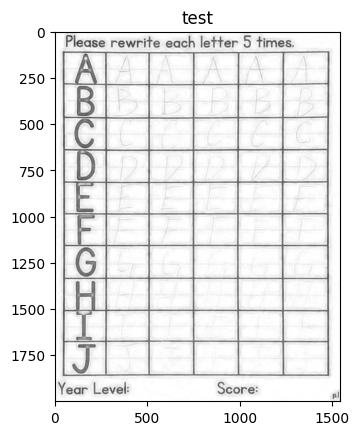

In [4]:
show_img(image, "test")

In [5]:
import cv2
import numpy as np

# Create or load a binary image
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Find connected components
(num_labels, label_ids, values, centroid) = cv2.connectedComponentsWithStats(binary)

mask = np.zeros(binary.shape, dtype="uint8")

for i in range(num_labels):
    
    x = values[i, cv2.CC_STAT_LEFT]
    y = values[i, cv2.CC_STAT_TOP]
    w = values[i, cv2.CC_STAT_WIDTH]
    h = values[i, cv2.CC_STAT_HEIGHT]
    area = values[i, cv2.CC_STAT_AREA]
    # area = values[i, cv2.CC_STAT_AREA]  
    
    # keepWidth = w > 5 and w < 100
    # keepHeight = h > 45 and h < 100
    # keepArea = area > 500 and area < 1500
    # if all((keepWidth, keepHeight, keepArea)):
        # construct a mask for the current connected component and
        # then take the bitwise OR with the mask
    # print("[INFO] keeping connected component '{}'".format(i))
    componentMask = (labels == i).astype("uint8") * 255
    mask = cv2.bitwise_or(mask, componentMask)

    # if (area > 0) and (area < 20000):
            
    # 	keepWidth = w > 5 and w < 50
    # 	keepHeight = h > 45 and h < 65
    # 	keepArea = area > 500 and area < 1500
    #     # Labels stores all the IDs of the components on the each pixel
    #     # It has the same dimension as the threshold
    #     # So we'll check the component
    #     # then convert it to 255 value to mark it white
    #     componentMask = (label_ids == i).astype("uint8") * 255
        
    #     # Creating the Final output mask
    #     output = cv2.bitwise_or(output, componentMask)

# print(f"Number of components (including background): {num_labels}")
# print(f"Labels shape: {labels.shape}")
# print(f"Unique labels: {np.unique(labels)}")

# # Visualize components with different colors
# label_hue = np.uint8(179 * labels / np.max(labels))
# blank_ch = 255 * np.ones_like(label_hue)
# labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
# labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)
# labeled_img[label_hue == 0] = 0  # Set background to black

# cv2.imshow('Connected Components', labeled_img)
# cv2.waitKey(0)
show_img(mask, 'labeled')

NameError: name 'labels' is not defined

In [ ]:
# Applying threshold
blurred = cv2.GaussianBlur(image, (7,7), cv2.BORDER_DEFAULT)
threshold = cv2.threshold(blurred, 0, 255,
cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]

Found 7 uniform square grids


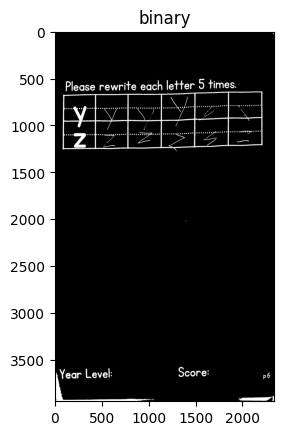

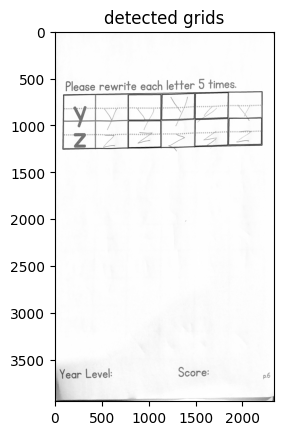

In [33]:
# def get_uniform_square_grids(image, size_tolerance=0.5):
#     """
#     Get square grids that have similar sizes (uniform grid)
    
#     Parameters:
#     - size_tolerance: acceptable variation in size (0.2 = 20%)
#     """
#     # Get all squares first
#     num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(image, connectivity=8)
    
#     squares = []
#     areas = []
    
#     for i in range(1, num_labels):
#         x, y, w, h, area = stats[i]
        
#         if area < 1000:
#             continue
        
#         aspect_ratio = float(w) / float(h) if h > 0 else 0
        
#         # if 0.3 <= aspect_ratio <= 1.15:
#         squares.append({
#             'bbox': (x, y, w, h),
#             'area': area,
#             'centroid': centroids[i],
#             'label': i
#         })
#         areas.append(area)
    
#     if not areas:
#         return []
    
#     # Filter by uniform size
#     median_area = np.median(areas)
#     filtered_squares = []
    
#     for square in squares:
#         area_ratio = square['area'] / median_area
#         if (1 - size_tolerance) <= area_ratio <= (1 + size_tolerance):
#             filtered_squares.append(square)
    
#     return filtered_squares

def angle_cos(p0, p1, p2):
    d1, d2 = (p0-p1).astype('float'), (p2-p1).astype('float')
    return abs( np.dot(d1, d2) / np.sqrt( np.dot(d1, d1)*np.dot(d2, d2) ) )

def get_uniform_square_grids(bin, size_tol=0):
    squares = []
    contours, _hierarchy = cv.findContours(bin, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        cnt_len = cv.arcLength(cnt, True)
        cnt = cv.approxPolyDP(cnt, 0.02*cnt_len, True)
        if len(cnt) == 4 and cv.contourArea(cnt) > 1000 and cv.isContourConvex(cnt):
            cnt = cnt.reshape(-1, 2)
            max_cos = np.max([angle_cos( cnt[i], cnt[(i+1) % 4], cnt[(i+2) % 4] ) for i in range(4)])
            if max_cos < 0.1:
                squares.append(cnt)
    return squares
    
# Example: Complete grid detection with filtering
def detect_writing_grid(image_path):
    """Complete example for detecting writing grids"""
    image = cv2.imread(image_path, 0)
    
    if image is None:
        print("Error: Could not load image!")
        return
    
    # Preprocess
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Morphological operations to clean up
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    
    # Get uniform square grids
    squares = get_uniform_square_grids(binary)
    
    print(f"Found {len(squares)} uniform square grids")
    
    # Visualize
    output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    
    show_img(binary, "binary")
    output = cv.drawContours( image, squares, -1, (0, 255, 0), 3 )
    show_img(output, "detected grids")

    return len(squares)


if __name__ == "__main__":
    squares = detect_writing_grid("./worksheets/y-z.png")